<h1 style="text-align: center; color: darkblue;">EDA and Quick Prototyping</h1>

### 📑 <font color='blue'> Table of Contents </font>
1. [Introduction](#1)
2. [Setup](#2)
3. [Loading and inspecting data](#3)
4. [Models](#4) <br>
    4.1. [Baseline](#4.1) <br>
    4.2. [Tree](#4.2) <br>
    4.3. [Random Forest](#4.3) <br>
    4.4. [Neural Network](#4.4)
5. [Annex](#annex) <br>
    A. [Class Imbalance](#A) <br>
    B. [Custom metric in Tuner](#B) <br>

## <a id="1" style="color: darkred; text-decoration: none;">1. Introduction</a>

In this notebook, we explore Industrial Control System (ICS) network traffic data with the goal of understanding its structure and behavior. We’ll perform Exploratory Data Analysis (EDA) to identify key patterns, relationships, and potential challenges within the dataset — such as class imbalance or feature correlations.

After gaining insights from the data, we’ll move into quick prototyping by training a few simple supervised models to classify network traffic into categories such as benign, DoS, DoS Hulk, and others.

The objective here is not to build the most accurate model, but to:

- Develop an initial understanding of the data.

- Identify which features or preprocessing steps might be useful.

- Evaluate baseline models to guide future, more sophisticated experiments.

This notebook serves as a foundation for deeper modeling and optimization later in the pipeline.

## <a id="2" style="color: darkred; text-decoration: none;"> 2.Setup </a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import copy

from ray import tune
from ray.tune.schedulers import ASHAScheduler

In [2]:
pd.set_option("display.max_rows", None)       # show all rows
pd.set_option("display.max_columns", None)    # show all columns
pd.set_option("display.width", None)          # don't wrap lines
pd.set_option("display.max_colwidth", None)   # show full cell content

## <a id="3" style="color: darkred; text-decoration: none;"> 3. Loading and inspecting data </a>

Given the restricted resources and the fact that this is a portfolio project, I will use a subset of the ICS Dataset

The CICIDS2017 dataset consists of labeled network flows, including full packet payloads in pcap format, the corresponding profiles and the labeled flows (GeneratedLabelledFlows.zip) and CSV files for machine and deep learning purpose (MachineLearningCSV.zip) are publicly available for researchers. [Link](https://www.unb.ca/cic/datasets/ids-2017.html)

Iman Sharafaldin, Arash Habibi Lashkari, and Ali A. Ghorbani, “Toward Generating a New Intrusion Detection Dataset and Intrusion Traffic Characterization”, 4th International Conference on Information Systems Security and Privacy (ICISSP), Portugal, January 2018.


In [20]:
df = pd.read_csv("../data/data.csv", encoding="latin1")
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,61900,54,2,2,4,12,2,2,2.000000,0.000000,6,6,6.000000,0.000000,296296.296300,74074.074070,1.800000e+01,2.605763e+01,48,1,1,1.00,0.000000e+00,1,1,48,48.0,0.000000e+00,48,48,0,0,0,0,48,40,37037.037040,37037.037040,2,6,3.600000,2.190890,4.800,0,0,0,1,0,0,0,0,1,4.500000,2.000000,6.000000,48,0,0,0,0,0,0,2,4,2,12,1024,0,1,24,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,24800,49,2,0,4,0,2,2,2.000000,0.000000,0,0,0.000000,0.000000,81632.653060,40816.326530,4.900000e+01,0.000000e+00,49,49,49,49.00,0.000000e+00,49,49,0,0.0,0.000000e+00,0,0,0,0,0,0,48,0,40816.326530,0.000000,2,2,2.000000,0.000000,0.000,0,0,0,1,0,0,0,0,0,3.000000,2.000000,0.000000,48,0,0,0,0,0,0,2,4,0,0,1024,-1,1,24,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,443,5885346,9,6,710,3826,517,0,78.888889,172.656773,1448,0,637.666667,672.176663,770.727838,2.548703,4.203819e+05,1.489591e+06,5592381,2,5885346,735668.25,1.963602e+06,5592381,16,268090,53618.0,1.008750e+05,232654,191,0,0,0,0,296,200,1.529222,1.019481,0,1448,283.500000,497.149072,247157.200,0,0,0,1,0,0,0,0,0,302.400000,78.888889,637.666667,296,0,0,0,0,0,0,9,710,6,3826,29200,65,3,32,292949.0,0.0,292949,292949,5592381.0,0.0,5592381,5592381,BENIGN
3,49738,57,1,1,0,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,35087.719298,5.700000e+01,0.000000e+00,57,57,0,0.00,0.000000e+00,0,0,0,0.0,0.000000e+00,0,0,0,0,0,0,32,32,17543.859649,17543.859649,0,0,0.000000,0.000000,0.000,0,0,0,0,1,1,0,0,1,0.000000,0.000000,0.000000,32,0,0,0,0,0,0,1,0,1,0,332,229,0,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,80,98306933,6,7,363,11595,345,0,60.500000,139.406958,4355,0,1656.428571,2121.983652,121.639437,0.132239,8.192244e+06,2.840000e+07,98300000,3,98300000,19700000.00,4.400000e+07,98300000,990,98300000,16400000.0,4.010000e+07,98300000,15,0,0,0,0,164,232,0.061033,0.071206,0,4355,854.571429,1666.831481,2778327.187,1,0,0,0,0,0,0,0,1,920.307692,60.500000,1656.428571,164,0,0,0,0,0,0,6,363,7,11595,0,235,3,20,14018.0,0.0,14018,14018,98300000.0,0.0,98300000,98300000,DoS Hulk


In [21]:
df.shape

(79998, 79)

In [22]:
# basic summary
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isna().sum(),
    "unique": df.nunique(),
})

print(summary.to_string())



                               dtype  missing  unique
Destination Port               int64        0   10832
Flow Duration                  int64        0   44162
Total Fwd Packets              int64        0     286
Total Backward Packets         int64        0     339
Total Length of Fwd Packets    int64        0    3823
Total Length of Bwd Packets    int64        0    7091
Fwd Packet Length Max          int64        0    1951
Fwd Packet Length Min          int64        0     152
Fwd Packet Length Mean       float64        0    8630
Fwd Packet Length Std        float64        0   12967
Bwd Packet Length Max          int64        0    2119
Bwd Packet Length Min          int64        0     346
Bwd Packet Length Mean       float64        0    9577
Bwd Packet Length Std        float64        0   11191
Flow Bytes/s                 float64       38   54486
Flow Packets/s               float64        0   47913
Flow IAT Mean                float64        0   46201
Flow IAT Std                

**Handle duplicates**

In [23]:
print("Number of Duplicates:", df.duplicated().sum())

# drop duplicates
df = df.drop_duplicates()
df = df.dropna()

print("Sanity check:", df.duplicated().sum())

Number of Duplicates: 2649
Sanity check: 0


**Handle infinities**

In [24]:
print("Infinities:", np.isinf(df.select_dtypes(include=[np.number])).any().any())

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna()

print("Sanity check:", np.isinf(df.select_dtypes(include=[np.number])).any().any())


Infinities: True
Sanity check: False


**Handle missing values (NaN, None..)**

In [25]:
# Count NaNs per column
print(df.isna().sum())

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
Total Length of Bwd Packets    0
Fwd Packet Length Max          0
Fwd Packet Length Min          0
Fwd Packet Length Mean         0
Fwd Packet Length Std          0
Bwd Packet Length Max          0
Bwd Packet Length Min          0
Bwd Packet Length Mean         0
Bwd Packet Length Std          0
Flow Bytes/s                   0
Flow Packets/s                 0
Flow IAT Mean                  0
Flow IAT Std                   0
Flow IAT Max                   0
Flow IAT Min                   0
Fwd IAT Total                  0
Fwd IAT Mean                   0
Fwd IAT Std                    0
Fwd IAT Max                    0
Fwd IAT Min                    0
Bwd IAT Total                  0
Bwd IAT Mean                   0
Bwd IAT Std                    0
Bwd IAT Max                    0
Bwd IAT Min                    0
Fwd PSH Fl

There are no missing values, but if there were, I could, for ecxample, drop columns with more than 50% missing values.

```
threshold = 0.5
df = df.loc[:, df.isna().mean() < threshold]
```

**Label distribution**

In [26]:
# Count rows per class
label_counts = df['Label'].value_counts()
print("\033[1mLabel counts\n\033[0m\n", label_counts)


print("--------------------------------------\n")

# Percentage of each class
label_percent = df['Label'].value_counts(normalize=True) * 100
print("\033[1mLabel counts (%)\n\033[0m\n", label_percent)

Label counts

 BENIGN                        63101
DoS Hulk                       5162
PortScan                       4373
DDoS                           3618
DoS GoldenEye                   291
FTP-Patator                     189
DoS slowloris                   162
DoS Slowhttptest                155
SSH-Patator                     138
Bot                              54
Web Attack ï¿½ Brute Force       43
Web Attack ï¿½ XSS               19
Name: Label, dtype: int64
--------------------------------------

Label counts (%)

 BENIGN                        81.626027
DoS Hulk                       6.677446
PortScan                       5.656814
DDoS                           4.680163
DoS GoldenEye                  0.376431
FTP-Patator                    0.244486
DoS slowloris                  0.209560
DoS Slowhttptest               0.200504
SSH-Patator                    0.178514
Bot                            0.069853
Web Attack ï¿½ Brute Force     0.055624
Web Attack ï¿½ XSS          

The dataset is highly imbalanced: BENIGN traffic dominates with over 81%, followed by DoS Hulk (6.7%), PortScan (5.7%), and DDoS (4.7%). The remaining classes each represent less than 0.4% of the data, indicating they are extremely underrepresented.

Classes such as Bot, Web Attack – Brute Force, and Web Attack – XSS account for less than 0.1% each. These are rare events, making it difficult for a model to learn meaningful patterns from so few samples.
To improve class balance and ensure more reliable learning, I’ll merge them into a single “Rare Attacks” category. This preserves their contribution to the dataset while reducing fragmentation among underrepresented classes

In [27]:
# Define rare attacks to combine
rare_attacks = ['Bot', 'Web Attack � Brute Force', 'Web Attack � XSS']

# Create a new column or overwrite Label
df['Label'] = df['Label'].apply(lambda x: 'Other_Attack' if x in rare_attacks else x)

# Check the new class distribution
print(df['Label'].value_counts(),"\n")
print(df['Label'].value_counts(normalize=True) * 100)

BENIGN                        63101
DoS Hulk                       5162
PortScan                       4373
DDoS                           3618
DoS GoldenEye                   291
FTP-Patator                     189
DoS slowloris                   162
DoS Slowhttptest                155
SSH-Patator                     138
Other_Attack                     54
Web Attack ï¿½ Brute Force       43
Web Attack ï¿½ XSS               19
Name: Label, dtype: int64 

BENIGN                        81.626027
DoS Hulk                       6.677446
PortScan                       5.656814
DDoS                           4.680163
DoS GoldenEye                  0.376431
FTP-Patator                    0.244486
DoS slowloris                  0.209560
DoS Slowhttptest               0.200504
SSH-Patator                    0.178514
Other_Attack                   0.069853
Web Attack ï¿½ Brute Force     0.055624
Web Attack ï¿½ XSS             0.024578
Name: Label, dtype: float64


**Keep only relevant features**

To select a subset of features, we can start by consulting an expert in the field, then explore correlations as a first step, and finally evaluate feature importance after training a model.
In this project, to keep things simple, we’ll begin by using all the available features. However, if we later decide to select only a few, we can write code like this:

```
selected_features = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Label'  # keep the target
]
df_small = df[selected_features]
```


**Label encoding**

In [28]:
# Create encoder
le = LabelEncoder()

# Fit and transform the Label column
df['Label'] = le.fit_transform(df['Label'])

# See the mapping of classes
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label mapping:", label_mapping)


Label mapping: {'BENIGN': 0, 'DDoS': 1, 'DoS GoldenEye': 2, 'DoS Hulk': 3, 'DoS Slowhttptest': 4, 'DoS slowloris': 5, 'FTP-Patator': 6, 'Other_Attack': 7, 'PortScan': 8, 'SSH-Patator': 9, 'Web Attack ï¿½ Brute Force': 10, 'Web Attack ï¿½ XSS': 11}


**Separe features and labels**

In [29]:
# X = features, y = target
X = df.drop('Label', axis=1)
y = df['Label']

y.iloc[0:3]

0    0
1    0
2    0
Name: Label, dtype: int64

**Train/val split**

In [30]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,      # preserves class distribution
    random_state=42
)

print("Train/Val shape:", X_train.shape)
print("Test shape:", X_val.shape)

Train/Val shape: (61844, 78)
Test shape: (15461, 78)


**Smote**

In [31]:
# -----------------------------
# Apply SMOTE only for minority classes
# -----------------------------

# Let's upsample classes with < 2000 samples
minority_classes = y_train.value_counts()[y_train.value_counts() < 2000].index.tolist()
sampling_dict = {cls: 2000 for cls in minority_classes}  # generate 2000 samples per rare class

smote = SMOTE(sampling_strategy=sampling_dict, random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

print("Class counts after SMOTE:")
print(pd.Series(y_res).value_counts())

Class counts after SMOTE:
0     50481
3      4130
8      3498
1      2895
9      2000
4      2000
6      2000
7      2000
10     2000
5      2000
2      2000
11     2000
Name: Label, dtype: int64


**Scaling (only for neural nets)**

In [32]:
# -----------------------------
# Scale features
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # fit and transform
X_val_scaled = scaler.transform(X_val) # only transform

**Putting it all together**


We can combine all preprocessing steps into a single function. Note that:

- If specific features are provided, we’ll use that subset; otherwise, we’ll work with all available features.

- We can choose whether to apply SMOTE or not.

- The same applies to scaling — it can be applied when needed (remember, tree-based models don’t require scaling).

In [3]:
def preprocessing(data_path, features=None, smote=False, scaling=False):

    # Load data
    df = pd.read_csv(data_path, encoding="latin1")

    # Drop duplicates and handle infinities
    df = df.drop_duplicates()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df = df.dropna()

    # Combine rare attacks
    rare_attacks = ['Bot', 'Web Attack – Brute Force', 'Web Attack – XSS']
    df['Label'] = df['Label'].apply(lambda x: 'Other_Attack' if x in rare_attacks else x)

    # Select subset of features if provided
    if features:
        df = df[features + ['Label']]

    # Label encoding
    le = LabelEncoder()
    df['Label'] = le.fit_transform(df['Label'])

    # Separate features and labels
    X = df.drop('Label', axis=1)
    y = df['Label']

    # Train/validation split
    X_train, X_val, y_train, y_val = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    # Apply SMOTE if requested
    if smote:
        sm = SMOTE(random_state=42)
        X_train, y_train = sm.fit_resample(X_train, y_train)

    # Apply scaling if requested
    if scaling:
        # instanciate scaler
        scaler = StandardScaler()
        
        # fit (only with training data)        
        scaler.fit(X_train)

        # Scale training set
        X_train = pd.DataFrame(
            scaler.transform(X_train),
            columns=X_train.columns,
            index=X_train.index
        )

        # Scale validation set
        X_val = pd.DataFrame(
            scaler.transform(X_val),
            columns=X_val.columns,
            index=X_val.index
        )

    return X_train.values, X_val.values, y_train.values, y_val.values


## <a id="4" style="color: darkred; text-decoration: none;"> 4. Models </a>


### <a id="4.1" style="color: darkorange; text-decoration: none;"> 4.1. Baseline </a>


As a baseline, I’ll use Logistic Regression, since it’s a simple yet effective model that can handle multiclass classification and provides a solid reference point for comparing more complex models later.

In [19]:
# baseline
from sklearn.linear_model import LogisticRegression

# data
X_train, X_val, y_train, y_val = preprocessing("../data/data.csv", smote=True, scaling=True)

# train and eval model
lr = LogisticRegression(max_iter=2000, multi_class='multinomial', solver='lbfgs')
lr.fit(X_train, y_train)
y_val_pred = lr.predict(X_val)
print(classification_report(y_val, y_val_pred, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      0.88      0.93     12620
           1       0.84      1.00      0.91       723
           2       0.65      0.91      0.76        58
           3       0.85      0.99      0.92      1032
           4       0.60      0.97      0.74        31
           5       0.51      1.00      0.67        32
           6       0.37      1.00      0.54        38
           7       0.02      0.91      0.03        11
           8       0.82      1.00      0.90       875
           9       0.15      1.00      0.25        28
          10       0.11      0.44      0.17         9
          11       0.06      1.00      0.12         4

    accuracy                           0.90     15461
   macro avg       0.50      0.93      0.58     15461
weighted avg       0.96      0.90      0.93     15461



/home/marcos/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


- Overall performance: 
    - Accuracy is 0.90, and the weighted F1 (0.93) is strong — the model performs well overall, driven by dominant classes like 0, 1, 3, and 8.

- Macro vs. weighted averages: 
    - The macro F1 (0.58) is much lower, indicating class imbalance and poor performance on rare classes.

- Minority classes: 
    - Classes with very few samples (e.g., 4–11) show high recall but very low precision — the model predicts them often incorrectly but almost never misses them.

- Pattern: 
    - The model tends to overpredict minority classes (recall = 1.00 for several, precision < 0.6), which inflates recall but hurts precision.

<b> <font color='blue'> Conclusion: </font> </b>
- Excellent on frequent classes (0, 1, 3, 8).

- Overfitting or recall-heavy bias on rare classes.

- Needs better class balance handling (e.g., class weighting, focal loss, or data augmentation).


**Note:** The logistic regression model reached the maximum number of iterations before full convergence, suggesting that the optimization didn’t completely stabilize. Despite this, it achieved strong performance on major classes, but the imbalance among minor classes caused recall-heavy behavior and low precision for rare labels. Increasing max_iter or scaling the data could help the model converge properly and potentially improve stability across all classes.

### <a id="4.2" style="color: darkorange; text-decoration: none;"> 4.2. Tree </a>

In [4]:
from sklearn.tree import DecisionTreeClassifier

# data
X_train, X_val, y_train, y_val = preprocessing("../data/data.csv", smote=True)


# Create and train tree model
tree = DecisionTreeClassifier(
    criterion='gini',  # or 'entropy'
    max_depth=10,      # limit depth to avoid overfitting
    random_state=42
)
tree.fit(X_train, y_train)

# Evaluate
y_pred = tree.predict(X_val)

print(confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred, digits=3, zero_division=0)) 
            #zero_division=0 avoids warnings for classes with no predicted samples.




[[12033     1   226   181    29    18     1    77    40     0     3    11]
 [    1   722     0     0     0     0     0     0     0     0     0     0]
 [    1     0    56     1     0     0     0     0     0     0     0     0]
 [    1     1     0  1030     0     0     0     0     0     0     0     0]
 [    0     0     2     0    29     0     0     0     0     0     0     0]
 [    0     0     0     0     0    32     0     0     0     0     0     0]
 [    0     0     0     0     0     0    38     0     0     0     0     0]
 [    1     0     0     0     0     0     0    10     0     0     0     0]
 [    0     0     0     0     0     0     0     0   875     0     0     0]
 [    0     0     0     0     0     0     0     0     0    28     0     0]
 [    1     0     0     0     0     0     0     0     0     0     6     2]
 [    0     0     0     0     0     0     0     0     0     0     2     2]]
              precision    recall  f1-score   support

           0      1.000     0.953     0.976 

- Overall performance: 
    - Accuracy improved to 0.961, and the weighted F1 (0.969) is excellent.

- Macro vs. weighted averages: 
    - The macro F1 (0.719) is still lower than the weighted one, meaning that minority classes continue to underperform, though less severely than before.

- Major classes (0, 1, 3, 8): 
    - Extremely strong — all have precision, recall, and F1 near or above 0.95. These dominate the overall accuracy.

- Minor classes (2, 4, 7, 10, 11): 
    - Still show very high recall but weak precision, indicating overprediction or confusion with similar labels. For example, class 2 (recall 0.97, precision 0.20) suggests the model predicts class 2 too often.


<b> <font color='blue'> Conclusion: </font> </b>

- The model converged much better — excellent global performance.

- Class imbalance persists; small classes inflate recall at the cost of precision.

- Further tuning (e.g., class weights or oversampling) could balance minority class precision without harming overall accuracy.

### <a id="4.3" style="color: darkorange; text-decoration: none;"> 4.3. Random Forest </a>

In [5]:
from sklearn.ensemble import RandomForestClassifier

# data
X_train, X_val, y_train, y_val = preprocessing("../data/data.csv", smote=True)

# Create the Random Forest classifier
rf = RandomForestClassifier(
    n_estimators=5,    # number of trees
    max_depth=None,      # allow trees to grow fully
    random_state=42,
    n_jobs=-1            # use all cores
)

# Train the model
rf.fit(X_train, y_train)

# Predict on validation set
y_val_pred = rf.predict(X_val)

# Evaluate performance
print("Classification Report:\n")
print(classification_report(y_val, y_val_pred, zero_division=0))

print("Confusion Matrix:\n")
print(pd.DataFrame(confusion_matrix(y_val, y_val_pred), 
                   index=rf.classes_, columns=rf.classes_))

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12620
           1       1.00      1.00      1.00       723
           2       1.00      0.97      0.98        58
           3       0.99      1.00      0.99      1032
           4       0.90      0.90      0.90        31
           5       1.00      1.00      1.00        32
           6       1.00      1.00      1.00        38
           7       0.62      0.91      0.74        11
           8       0.99      1.00      1.00       875
           9       1.00      0.96      0.98        28
          10       0.43      0.33      0.38         9
          11       0.25      0.50      0.33         4

    accuracy                           1.00     15461
   macro avg       0.85      0.88      0.86     15461
weighted avg       1.00      1.00      1.00     15461

Confusion Matrix:

       0    1   2     3   4   5   6   7    8   9   10  11
0   12593    1   0    11   3   0

- Overall performance: 
    - The model achieved almost perfect accuracy (≈1.00) and weighted F1 = 1.00, indicating it fits the training/test data exceptionally well.

- Macro averages: 
    - Slightly lower (≈0.86) due to weaker performance on very small classes (e.g., 7, 10, 11).

- Major classes (0–3, 5, 6, 8): 
    - Perfect or near-perfect — extremely high precision and recall, consistent with a well-learned decision boundary.

- Minor classes:
    - Class 7: High recall (0.91) but moderate precision (0.62).
    - Classes 10 & 11: Small support → unstable metrics (few samples lead to noisy precision/recall).

- Confusion matrix: 
    - Errors are minimal and localized (occasional confusion among rare classes), while the large classes show perfect diagonal dominance.

<b> <font color='blue'> Conclusion: </font> </b>

The Random Forest captures the dataset’s patterns very well — perhaps too well, suggesting possible overfitting.


### <a id="4.4" style="color: darkorange; text-decoration: none;"> 4.4. Simple Neural Network </a>

Let's tune a simple neural network.


**Data**

In [6]:
# data
X_train, X_val, y_train, y_val = preprocessing("../data/data.csv", smote=True, scaling=True)

# fn. to create data loaders
def create_loaders(X_train, X_val, y_train, y_val):
    train_loader = DataLoader(
            TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                          torch.tensor(y_train, dtype=torch.long)),
            batch_size=64, shuffle=True
        )

    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_val, dtype=torch.float32),
                      torch.tensor(y_val, dtype=torch.long)),
        batch_size=64, shuffle=False
    )
    
    return train_loader, val_loader

**Model**

In [7]:
# -----------------------------
# Define a simple feedforward NN
# -----------------------------
class nn_model(nn.Module):
    def __init__(self, input_size, num_classes, hidden1=128, hidden2=64, dropout=0.0):
        super(nn_model, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, num_classes)
        )

    def forward(self, x):
        return self.model(x)
    


In [8]:
# input size and num classes
input_size = X_train.shape[1]
num_classes = n_classes = np.unique(y_train).size # change latter, maybe return it in prepimport copy

**Train function**

We will write a training function that works both for tuning with Ray Tune and later for training the best model.


In [9]:
# train model
def train_model(config, X_train, y_train, X_val, y_val, input_size, num_classes, **kwargs):
    
    tuning = kwargs.get("tuning", False)
    num_epochs = kwargs.get("num_epochs", 5)
    patience = kwargs.get("patience", 3)
    epochs_no_improve = kwargs.get("epochs_no_improve", 0)
    
    best_val_acc = 0
    
    # Ensure numpy arrays (in case user passes DataFrames)
    if hasattr(X_train, "values"):
        X_train = X_train.values
    if hasattr(y_train, "values"):
        y_train = y_train.values
    if hasattr(X_val, "values"):
        X_val = X_val.values
    if hasattr(y_val, "values"):
        y_val = y_val.values
        
    # Dataloaders
    train_loader, val_loader = create_loaders(X_train, X_val, y_train, y_val)
    
    # create model
    model = nn_model(
        input_size=input_size,
        num_classes=num_classes,
        hidden1=config["hidden1"],
        hidden2=config["hidden2"],
        dropout=config["dropout"]
    )
    
    best_model = copy.deepcopy(model.state_dict())

    # criterion and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config["lr"])

    # Training
    for epoch in range(num_epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
        

        # Validation accuracy
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                _, predicted = torch.max(outputs, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()
        val_acc = correct / total
        
        if not tuning:
            print(f"Epoch {epoch+1}/{num_epochs}, Validation Accuracy: {val_acc:.4f}")
        
        # If tuning report result to Ray Tune
        if tuning:
            tune.report({"val_accuracy": val_acc})
    
    
        # Early stopping check
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break
        
    # if not tuning return best model
    if not tuning:
        return best_model





**Tuning**

In [10]:
# search space
search_space = {
    "lr": tune.loguniform(1e-4, 1e-2),
    "batch_size": tune.choice([32, 64, 128]),
    "hidden1": tune.choice([64, 128, 256]),
    "hidden2": tune.choice([32, 64, 128]),
    "dropout": tune.uniform(0.0, 0.5)
}

scheduler = ASHAScheduler(metric="val_accuracy", mode="max")


tuner = tune.Tuner(
    tune.with_resources(
        tune.with_parameters(
            train_model,
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            input_size=input_size,
            num_classes=num_classes,
            tuning=True,
        ),
        resources={"cpu": 2}
    ),
    tune_config=tune.TuneConfig(
        num_samples=3,  # number of configs to test
        scheduler=scheduler
    ),
    param_space=search_space,
)

results = tuner.fit()

best_result = results.get_best_result("val_accuracy", "max")
print("Best config:", best_result.config)
print("Best accuracy:", best_result.metrics["val_accuracy"])


2025-11-05 15:10:05,023	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/home/marcos/ray_results/train_model_2025-11-05_15-07-04' in 0.0045s.
2025-11-05 15:10:05,028	INFO tune.py:1041 -- Total run time: 177.30 seconds (177.27 seconds for the tuning loop).


Best config: {'lr': 0.0005602412373008844, 'batch_size': 64, 'hidden1': 64, 'hidden2': 32, 'dropout': 0.2362734290845414}
Best accuracy: 0.9485156199469633


**Train best model**

In [11]:
# train bets model
best_model_state = train_model(
    config=best_result.config,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    input_size=input_size,
    num_classes=num_classes,
    tuning=False,
    num_epochs=10,
)


Epoch 1/10, Validation Accuracy: 0.9127
Epoch 2/10, Validation Accuracy: 0.9367
Epoch 3/10, Validation Accuracy: 0.9375
Epoch 4/10, Validation Accuracy: 0.9396
Epoch 5/10, Validation Accuracy: 0.9504
Epoch 6/10, Validation Accuracy: 0.9470
Epoch 7/10, Validation Accuracy: 0.9480
Epoch 8/10, Validation Accuracy: 0.9528
Epoch 9/10, Validation Accuracy: 0.9590
Epoch 10/10, Validation Accuracy: 0.9583


**Load best model**

In [12]:
best_config = best_result.config

model = nn_model(input_size=input_size, num_classes=num_classes,
                 hidden1=best_config["hidden1"],
                 hidden2=best_config["hidden2"],
                 dropout=best_config["dropout"])

model.load_state_dict(best_model_state)

model

nn_model(
  (model): Sequential(
    (0): Linear(in_features=78, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2362734290845414, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2362734290845414, inplace=False)
    (6): Linear(in_features=32, out_features=12, bias=True)
  )
)

**Evaluate on validation set**


Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.95      0.97     12620
           1       0.99      1.00      1.00       723
           2       0.70      0.98      0.82        58
           3       0.87      1.00      0.93      1032
           4       0.73      0.97      0.83        31
           5       0.84      1.00      0.91        32
           6       0.62      1.00      0.77        38
           7       0.05      0.91      0.10        11
           8       0.83      1.00      0.91       875
           9       0.87      0.96      0.92        28
          10       0.22      0.44      0.30         9
          11       0.13      1.00      0.24         4

    accuracy                           0.96     15461
   macro avg       0.66      0.93      0.72     15461
weighted avg       0.98      0.96      0.97     15461


Confusion Matrix:

       0    1   2     3   4   5   6    7    8   9   10  11
0   11999    4  20   157  11 

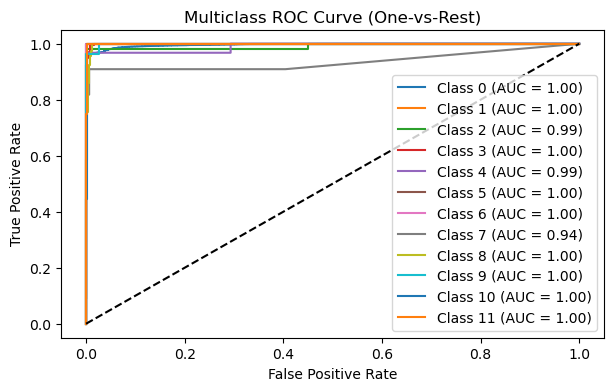

In [13]:
# Predictions
model.eval()
with torch.no_grad():
    y_val_pred_probs = model(torch.tensor(X_val, dtype=torch.float32))
    y_val_pred = torch.argmax(y_val_pred_probs, 1)

y_val_true = y_val
y_val_pred = y_val_pred.numpy()

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_val_true, y_val_pred, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_val_true, y_val_pred)
print("\nConfusion Matrix:\n")
print(pd.DataFrame(cm, index=range(num_classes), columns=range(num_classes)))

# ROC curve (One-vs-Rest)
y_val_onehot = nn.functional.one_hot(torch.tensor(y_val), num_classes=num_classes).numpy()
y_score = nn.Softmax(dim=1)(y_val_pred_probs).numpy()

plt.figure(figsize=(7,4))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_val_onehot[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve (One-vs-Rest)')
plt.legend(loc='lower right')
plt.show()

- Overall:

    - Accuracy = 0.96, weighted F1 = 0.97 — strong overall performance.

    - Macro F1 = 0.72 — the network still struggles with minority classes, but it’s performing consistently well on dominant ones.

- Major classes (0, 1, 3, 8):

    - Excellent precision and recall (≥0.95), driving the overall performance.

    - Misclassifications in class 0 are slightly higher (recall 0.95), with a few samples spilling into nearby classes (3, 7, 8).

- Minor classes (2, 4, 5, 6):

    - Much better than earlier models — precision and recall both high (>0.7–0.9).

    - Shows the network learned small-class representations well, thanks to tuning.

- Rare classes (7, 10, 11):

    - High recall but very low precision (especially 7: recall 0.91, precision 0.05).

    - Indicates a recall-oriented bias for underrepresented classes — typical when loss weighting or imbalance correction is applied.

- Confusion matrix pattern:

    - The largest confusion comes from class 0, which absorbs misclassifications from many small classes (e.g., 7, 11).

    - Minority classes are generally predicted correctly but at the cost of false positives.

<b> <font color='blue'> Conclusion: </font> </b>

- The model generalizes well — great validation metrics, no sign of overfitting.

- Still some precision–recall imbalance for rare classes.

- Potential improvements: focal loss, better class weighting, or data augmentation for low-support labels.

## <a id="annex" style="color: darkred; text-decoration: none;"> Annex </a>


### <a id="A" style="color: darkorange; text-decoration: none;"> A. Class Imbalance </a>


We have severla way sto deal with very unbalanced data like in this case.

**1. Data-Level Methods (Resampling)**

These modify the dataset before training.

- Undersampling:
    - Reduce samples from the majority class.
    - It is simple but can discard useful information.

- Oversampling:
    - Duplicate or synthetically create minority samples.
    - Increases recall; can risk overfitting.
    - For insance, we can use SMOTE (Synthetic Minority Over-sampling Technique).

- Hybrid approaches:
    - Combine both — e.g., undersample majority slightly and apply SMOTE to the minority.


**2. Algorithm-Level Methods (Cost-Sensitive Learning)**

Adjust the learning process instead of the data.

- Class weights:
    - Penalize misclassifying minority samples more heavily.

- Focal loss:
    - Focuses more on hard or minority samples.
    - It is often used in detection and network intrusion tasks.


Almost — just a small correction:


In these cases, we should use **metrics** that reflect imbalance better than accuracy, such as:


- Precision, Recall, F1-score (macro/weighted).

- ROC–AUC / PR–AUC.

- Confusion matrix per class.


### <a id="B" style="color: darkorange; text-decoration: none;"> B. Custom metric in Tuner </a>

Let's say that instead of choosing the best model only based on accuracy, we want to select it according to another criterion — for example, models with recall greater than a threshold, and among those, the one with the best F1 score. In that case, we would report F1 and recall to the tuner, and after obtaining all results, apply our custom selection criterion.

In [14]:
from sklearn.metrics import f1_score, recall_score


# train model
def train_model_v2(config, X_train, y_train, X_val, y_val, input_size, num_classes, **kwargs):
    

    num_epochs = kwargs.get("num_epochs", 5)

    
    # Ensure numpy arrays (in case user passes DataFrames)
    if hasattr(X_train, "values"):
        X_train = X_train.values
    if hasattr(y_train, "values"):
        y_train = y_train.values
    if hasattr(X_val, "values"):
        X_val = X_val.values
    if hasattr(y_val, "values"):
        y_val = y_val.values
        
    # Dataloaders
    train_loader, val_loader = create_loaders(X_train, X_val, y_train, y_val)
    
    # create model
    model = nn_model(
        input_size=input_size,
        num_classes=num_classes,
        hidden1=config["hidden1"],
        hidden2=config["hidden2"],
        dropout=config["dropout"]
    )
    
    best_model = copy.deepcopy(model.state_dict())

    # criterion and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config["lr"])

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
        
        # Validation accuracy
        model.eval()
        y_true = []
        y_pred = []
        with torch.no_grad():
            for xb, yb in val_loader:
                preds = model(xb)
                y_pred.extend(preds.argmax(dim=1).cpu().numpy())
                y_true.extend(yb.cpu().numpy())

        val_f1 = f1_score(y_true, y_pred, average='macro')
        val_recall = recall_score(y_true, y_pred, average='macro')
        
        # report both metrics to Ray Tune
        tune.report({"val_f1": float(val_f1), "val_recall": float(val_recall)})


        

In [15]:
# search space
search_space = {
    "lr": tune.loguniform(1e-4, 1e-2),
    "batch_size": tune.choice([32, 64, 128]),
    "hidden1": tune.choice([64, 128, 256]),
    "hidden2": tune.choice([32, 64, 128]),
    "dropout": tune.uniform(0.0, 0.5)
}

scheduler = ASHAScheduler(metric="val_f1", mode="max")


tuner = tune.Tuner(
    tune.with_resources(
        tune.with_parameters(
            train_model_v2,
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            input_size=input_size,
            num_classes=num_classes,
        ),
        resources={"cpu": 2}
    ),
    tune_config=tune.TuneConfig(
        num_samples=3,
        scheduler=scheduler
    ),
    param_space=search_space,
)

results = tuner.fit()


2025-11-05 15:16:29,461	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/home/marcos/ray_results/train_model_v2_2025-11-05_15-14-18' in 0.0041s.
2025-11-05 15:16:29,468	INFO tune.py:1041 -- Total run time: 130.90 seconds (130.87 seconds for the tuning loop).


In [16]:
results

ResultGrid<[
  Result(
    metrics={'val_f1': 0.7021811705411879, 'val_recall': 0.9338209793827271},
    path='/home/marcos/ray_results/train_model_v2_2025-11-05_15-14-18/train_model_v2_3ec82_00000_0_batch_size=32,dropout=0.1967,hidden1=256,hidden2=64,lr=0.0005_2025-11-05_15-14-18',
    filesystem='local',
    checkpoint=None
  ),
  Result(
    metrics={'val_f1': 0.631381248083637, 'val_recall': 0.8917615306460555},
    path='/home/marcos/ray_results/train_model_v2_2025-11-05_15-14-18/train_model_v2_3ec82_00001_1_batch_size=128,dropout=0.2493,hidden1=64,hidden2=128,lr=0.0064_2025-11-05_15-14-18',
    filesystem='local',
    checkpoint=None
  ),
  Result(
    metrics={'val_f1': 0.5757921547667145, 'val_recall': 0.8980639484149254},
    path='/home/marcos/ray_results/train_model_v2_2025-11-05_15-14-18/train_model_v2_3ec82_00002_2_batch_size=128,dropout=0.2195,hidden1=256,hidden2=32,lr=0.0002_2025-11-05_15-14-18',
    filesystem='local',
    checkpoint=None
  )
]>

In [17]:
def select_best_model(results, recall_threshold=0.9):
    """
    Selects the best model from a Ray Tune ResultGrid based on:
    - recall > recall_threshold
    - among those, the highest F1 score.

    Returns:
        dict with best result info (path, metrics, config, etc.)
        or None if no model meets the threshold.
    """
    candidates = []

    for r in results:
        metrics = r.metrics
        recall = metrics.get("val_recall", 0)
        f1 = metrics.get("val_f1", 0)

        if recall > recall_threshold:
            candidates.append({
                "result": r,
                "path": r.path,
                "metrics": metrics,
                "config": getattr(r, "config", None),
                "val_recall": recall,
                "val_f1": f1,
            })

    if not candidates:
        print(f"No models found with recall > {recall_threshold}")
        return None

    # Sort by F1 descending
    best = max(candidates, key=lambda x: x["val_f1"])

    print("✅ Best model selected:")
    print(f"  Recall: {best['val_recall']:.4f}")
    print(f"  F1: {best['val_f1']:.4f}")
    print(f"  Path: {best['path']}")
    if best["config"]:
        print(f"  Config: {best['config']}")

    return best


In [18]:
best = select_best_model(results, recall_threshold=0.9)
if best:
    best_metrics = best["metrics"]
    best_config = best["config"]
    best_path = best["path"]


✅ Best model selected:
  Recall: 0.9338
  F1: 0.7022
  Path: /home/marcos/ray_results/train_model_v2_2025-11-05_15-14-18/train_model_v2_3ec82_00000_0_batch_size=32,dropout=0.1967,hidden1=256,hidden2=64,lr=0.0005_2025-11-05_15-14-18
  Config: {'lr': 0.0004507567449128194, 'batch_size': 32, 'hidden1': 256, 'hidden2': 64, 'dropout': 0.19667925061484604}
